<a href="https://colab.research.google.com/github/Thanmaivarma1125/AI-ML-Internship-Maincrafts/blob/main/Maincrafts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =====================================================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# =====================================================================
# STEP 2: LOAD THE DATASET
# =====================================================================
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

# Display the first 5 rows to confirm it works
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
# STEP 3: SEPARATE FEATURES AND TARGET VARIABLE
# =====================================================================
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]
# STEP 4: FEATURE SCALING
# =====================================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features separated and scaled successfully!")

Features separated and scaled successfully!


In [3]:
# =====================================================================
# STEP 5: TRAIN-TEST SPLIT (80% Train, 20% Test)
# =====================================================================
# We need to re-import the updated RMSE function for newer scikit-learn versions
from sklearn.metrics import root_mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# =====================================================================
# STEP 6 & 7: TRAIN AND EVALUATE MULTIPLE MODELS (UPDATED FIXED VERSION)
# =====================================================================
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5)
}

results = {}

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    # Make predictions
    predictions = model.predict(X_test)

    # Calculate metrics using the updated function
    rmse = root_mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

# Display the performance comparison table
results_df = pd.DataFrame(results).T
results_df

,RMSE,R2 Score
Linear Regression,0.745581,0.575788
Ridge Regression,0.745554,0.575819
Decision Tree,0.724234,0.599732


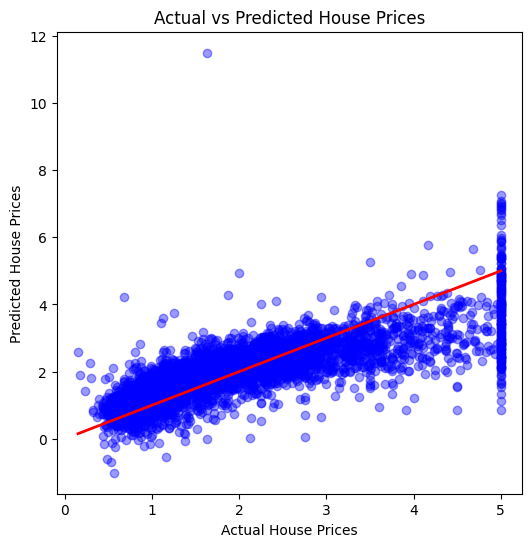

In [4]:
# =====================================================================
# STEP 8: VISUAL PERFORMANCE VALIDATION
# =====================================================================
# Using the baseline model for visual validation as requested
best_model = LinearRegression()
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Plotting actual vs predicted values
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4, color="blue")
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

# Add the perfect-fit reference diagonal line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", lw=2)
plt.show()